<a href="https://colab.research.google.com/github/heetaamin/Assignment-3/blob/main/Yeast/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 100)
plt.rcParams["figure.dpi"] = 110

# Load the file

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Dermatology/'

cols = [
    "erythema", "scaling", "definite_borders", "itching", "koebner_phenomenon",
    "polygonal_papules", "follicular_papules", "oral_mucosal_involvement",
    "knee_elbow_involvement", "scalp_involvement", "family_history",
    "melanin_incontinence", "eosinophils_infiltrate", "pnl_infiltrate",
    "fibrosis_papillary_dermis", "exocytosis", "acanthosis", "hyperkeratosis",
    "parakeratosis", "clubbing_rete_ridges", "elongation_rete_ridges",
    "thinning_suprapapillary_epidermis", "spongiform_pustule", "munro_microabcess",
    "focal_hypergranulosis", "disappearance_granular_layer",
    "vacuolisation_damage_basal_layer", "spongiosis", "saw_tooth_appearance_retes",
    "follicular_horn_plug", "perifollicular_parakeratosis",
    "inflammatory_monoluclear_infiltrate", "band_like_infiltrate", "age", "class"
]
df_raw = pd.read_csv(data_dir + "dermatology.data", names=cols, na_values="?")
print("Shape:", df_raw.shape)
df_raw.head()

Mounted at /content/drive
Shape: (366, 35)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


# Basic dataset structure

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   erythema                             366 non-null    int64  
 1   scaling                              366 non-null    int64  
 2   definite_borders                     366 non-null    int64  
 3   itching                              366 non-null    int64  
 4   koebner_phenomenon                   366 non-null    int64  
 5   polygonal_papules                    366 non-null    int64  
 6   follicular_papules                   366 non-null    int64  
 7   oral_mucosal_involvement             366 non-null    int64  
 8   knee_elbow_involvement               366 non-null    int64  
 9   scalp_involvement                    366 non-null    int64  
 10  family_history                       366 non-null    int64  
 11  melanin_incontinence            

Unlike Glass and Yeast, most of these features are ordinal (0-3 severity scores), not continuous measurements — 33 of the 34 features load as `int64`. `age` is the one linear/continuous feature, and it loads as `float64`, which is correct given it has missing values.

# Target value exploration

In [ ]:
print("Target variable:", "class")
print("Unique classes:", sorted(df_raw["class"].unique()))
print("Number of classes:", df_raw["class"].nunique())
df_raw["class"].value_counts().sort_index()

Target variable: class
Unique classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Number of classes: 6


,count
class,
1,112
2,61
3,72
4,49
5,52
6,20


# Missing values check

In [ ]:
print("Missing values (total):", df_raw.isna().sum().sum())
df_raw.isna().sum()

Missing values (total): 8


,0
erythema,0
scaling,0
definite_borders,0
itching,0
koebner_phenomenon,0
polygonal_papules,0
follicular_papules,0
oral_mucosal_involvement,0
knee_elbow_involvement,0
scalp_involvement,0


Only `age` has missing values (8 of 366, about 2.2%). This is new compared to Glass and Yeast, which had none — need to decide whether to impute or drop these rows before splitting.

# Exact duplicate rows check

In [ ]:
dup_mask = df_raw.duplicated(keep=False)
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
df_raw[dup_mask]

Duplicate rows: 0


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class


No exact duplicate rows, unlike Glass (which had 1). Nothing to drop — carrying `df_raw` forward as `df` for consistency with the later notebooks.

In [ ]:
df = df_raw.copy()
print("Shape:", df.shape)

Shape: (366, 35)


# Duplicate feature vectors with different labels check

In [ ]:
feature_cols = [c for c in df.columns if c != "class"]
feature_dup_mask = df.duplicated(subset=feature_cols, keep=False)
print("Rows with identical features but (possibly) different labels:", feature_dup_mask.sum())
df[feature_dup_mask].sort_values(feature_cols)

Rows with identical features but (possibly) different labels: 0


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_infiltrate,band_like_infiltrate,age,class


This is just to check if there is an irreducible error present

# Class distribution and minority to majority ordering

In [ ]:
CLASS_NAMES = {1: "psoriasis", 2: "seboreic_dermatitis", 3: "lichen_planus",
               4: "pityriasis_rosea", 5: "chronic_dermatitis", 6: "pityriasis_rubra_pilaris"}

counts = df["class"].value_counts().sort_values()
total = len(df)
dist_table = pd.DataFrame({
    "class_label": counts.index,
    "class_name": [CLASS_NAMES[c] for c in counts.index],
    "count": counts.values,
    "pct": (counts.values / total * 100).round(2),
})
dist_table["rank_minority_to_majority"] = range(1, len(dist_table) + 1)
dist_table

,class_label,class_name,count,pct,rank_minority_to_majority
0,6,pityriasis_rubra_pilaris,20,5.46,1
1,4,pityriasis_rosea,49,13.39,2
2,5,chronic_dermatitis,52,14.21,3
3,2,seboreic_dermatitis,61,16.67,4
4,3,lichen_planus,72,19.67,5
5,1,psoriasis,112,30.60,6


# Ordering and the imbalance ratio

In [ ]:
minority_to_majority_order = dist_table["class_label"].tolist()
imbalance_ratio = counts.max() / counts.min()

print("Minority -> majority order:", [CLASS_NAMES[c] for c in minority_to_majority_order])
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")

Minority -> majority order: ['pityriasis_rubra_pilaris', 'pityriasis_rosea', 'chronic_dermatitis', 'seboreic_dermatitis', 'lichen_planus', 'psoriasis']
Imbalance ratio (majority/minority): 5.60


# Class distribution bar chart

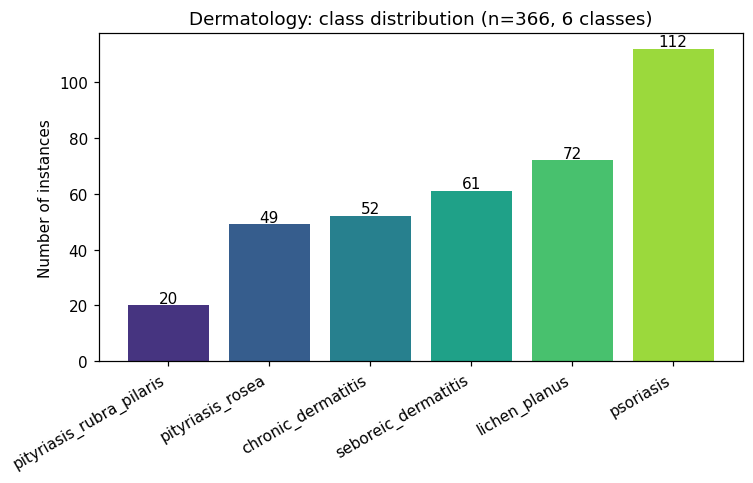

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(dist_table)))
ax.bar(dist_table["class_name"], dist_table["count"], color=colors)
for i, v in enumerate(dist_table["count"]):
    ax.text(i, v + 1, str(v), ha="center", fontsize=10)
ax.set_ylabel("Number of instances")
ax.set_title(f"Dermatology: class distribution (n={total}, 6 classes)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Descriptive statistics

In [ ]:
def continuous_dqr(df, cols):
    n = len(df)
    rows = []
    for c in cols:
        s = df[c]
        count = s.count()
        rows.append({
            "Feature": c, "Count": count, "% Miss.": round((n - count) / n * 100, 2),
            "Card.": s.nunique(), "Min.": s.min(), "1st Qrt.": s.quantile(0.25),
            "Mean": s.mean(), "Median": s.median(), "3rd Qrt.": s.quantile(0.75),
            "Max.": s.max(), "Std. Dev.": s.std(),
        })
    out = pd.DataFrame(rows)
    num_cols = ["Min.", "1st Qrt.", "Mean", "Median", "3rd Qrt.", "Max.", "Std. Dev."]
    out[num_cols] = out[num_cols].round(3)
    return out

def categorical_dqr(df, cols, label_map=None):
    n = len(df)
    rows = []
    for c in cols:
        s = df[c]
        count = s.count()
        vc = s.value_counts()
        mode, mode_freq = vc.index[0], int(vc.iloc[0])
        mode_pct = round(mode_freq / count * 100, 2)
        if len(vc) > 1:
            mode2, mode2_freq = vc.index[1], int(vc.iloc[1])
            mode2_pct = round(mode2_freq / count * 100, 2)
        else:
            mode2, mode2_freq, mode2_pct = np.nan, 0, 0.0
        if label_map:
            mode = f"{mode} ({label_map.get(mode, mode)})"
            mode2 = f"{mode2} ({label_map.get(mode2, mode2)})" if pd.notna(mode2) else mode2
        rows.append({
            "Feature": c, "Count": count, "% Miss.": round((n - count) / n * 100, 2),
            "Card.": s.nunique(), "Mode": mode, "Mode Freq.": mode_freq, "Mode %": mode_pct,
            "2nd Mode": mode2, "2nd Mode Freq.": mode2_freq, "2nd Mode %": mode2_pct,
        })
    return pd.DataFrame(rows)

# 32 ordinal (0-3) severity-score features + age get the continuous treatment,
# same as NUM CLAIMANTS/NUM SOFT TISSUE in the course's own DQR example -
# low-cardinality but genuinely ordered, so mean/median/quartiles are meaningful.
continuous_cols = [c for c in df.columns if c not in ["class", "family_history"]]
continuous_dqr_table = continuous_dqr(df, continuous_cols)

# family_history is a true binary presence/absence flag, not ordinal -
# same trap the slides warn about ("gender recorded as 0 or 1"), so it
# gets the categorical table instead.
categorical_dqr_table = categorical_dqr(df, ["family_history"])

# class is the TARGET, not a descriptive feature - its own table.
target_dqr_table = categorical_dqr(df, ["class"], label_map=CLASS_NAMES)

print("Continuous Descriptive Features — Data Quality Report")
display(continuous_dqr_table)

print("Categorical Descriptive Features — Data Quality Report")
display(categorical_dqr_table)

print("Target Feature — Data Quality Report")
display(target_dqr_table)

Continuous Descriptive Features — Data Quality Report


,Feature,Count,% Miss.,Card.,Min.,1st Qrt.,Mean,Median,3rd Qrt.,Max.,Std. Dev.
0,erythema,366,0.00,4,0.0,2.0,2.068,2.0,2.00,3.0,0.665
1,scaling,366,0.00,4,0.0,1.0,1.795,2.0,2.00,3.0,0.702
2,definite_borders,366,0.00,4,0.0,1.0,1.549,2.0,2.00,3.0,0.908
3,itching,366,0.00,4,0.0,0.0,1.366,1.0,2.00,3.0,1.138
4,koebner_phenomenon,366,0.00,4,0.0,0.0,0.634,0.0,1.00,3.0,0.908
5,polygonal_papules,366,0.00,4,0.0,0.0,0.448,0.0,0.00,3.0,0.957
6,follicular_papules,366,0.00,4,0.0,0.0,0.167,0.0,0.00,3.0,0.571
7,oral_mucosal_involvement,366,0.00,4,0.0,0.0,0.377,0.0,0.00,3.0,0.834
8,knee_elbow_involvement,366,0.00,4,0.0,0.0,0.615,0.0,1.00,3.0,0.983
9,scalp_involvement,366,0.00,4,0.0,0.0,0.519,0.0,1.00,3.0,0.906


Categorical Descriptive Features — Data Quality Report


,Feature,Count,% Miss.,Card.,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
0,family_history,366,0.0,2,0,320,87.43,1,46,12.57


Target Feature — Data Quality Report


,Feature,Count,% Miss.,Card.,Mode,Mode Freq.,Mode %,2nd Mode,2nd Mode Freq.,2nd Mode %
0,class,366,0.0,6,1 (psoriasis),112,30.6,3 (lichen_planus),72,19.67


`eosinophils_infiltrate` only reaches cardinality 3 (values 0-2), never using the full 0-3 range the other ordinal features do — worth keeping in mind if it behaves oddly later. `family_history` is heavily skewed toward 0 (no family history) at 87.4%.

# Outlier check via IQR (age only) - only actual continuous feature

In [ ]:
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3 - Q1
age_outliers = ((df["age"] < Q1 - 1.5*IQR) | (df["age"] > Q3 + 1.5*IQR)).sum()
print("Age outliers (IQR method):", age_outliers)

Age outliers (IQR method): 0


IQR-based outlier detection only makes sense for `age`, the one genuinely continuous feature. The other 32 features are bounded 0-3 ordinal severity scores — a value of 3 is the maximum of a defined scale, not a statistical anomaly, and 16 of these 32 features have Q1=Q3 (median stuck at 0), which would make the IQR method flag most nonzero values as "outliers" (up to 43% of the data for some features). That's a breakdown of the method on the wrong data type, not a real data-quality signal, so it's skipped for the ordinal features — their distributions are already covered by the DQR table's cardinality and mode statistics above.

# Correlation matrix

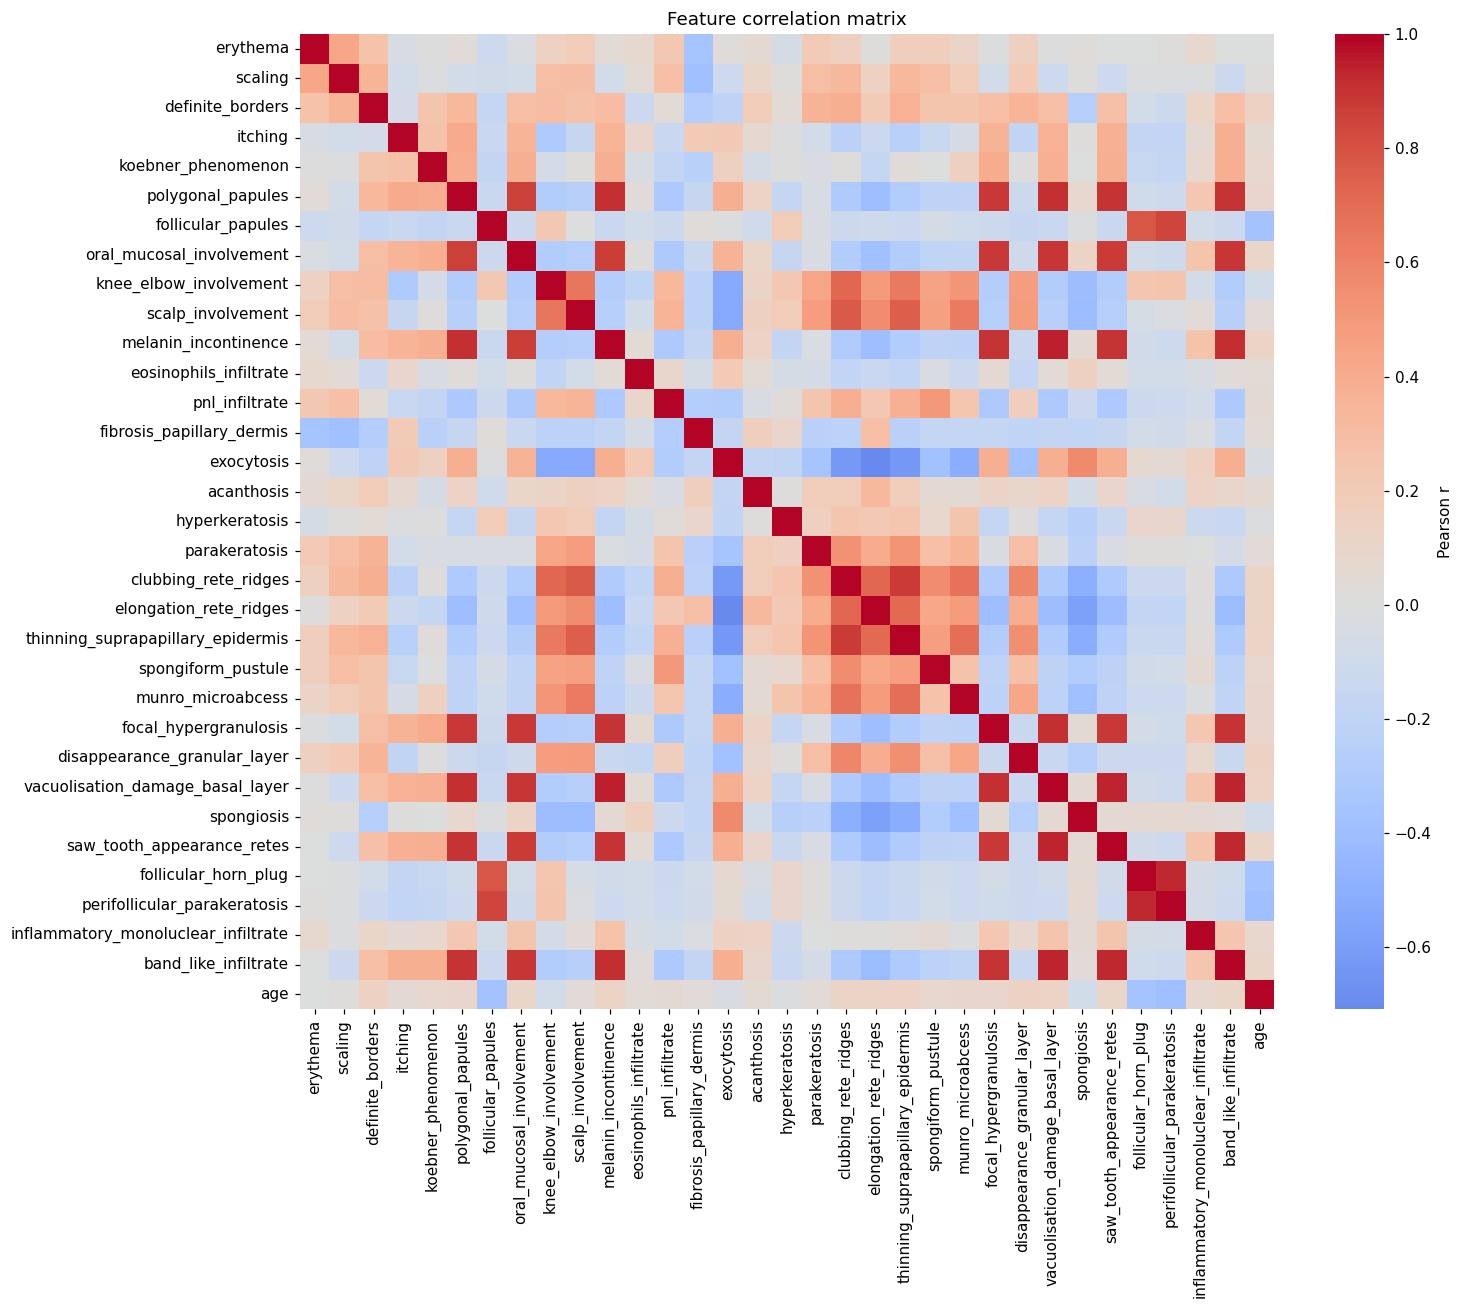

Feature pairs with |r| > 0.85: 23


melanin_incontinence              vacuolisation_damage_basal_layer     0.941659
vacuolisation_damage_basal_layer  saw_tooth_appearance_retes           0.938397
                                  band_like_infiltrate                 0.937561
follicular_horn_plug              perifollicular_parakeratosis         0.928929
saw_tooth_appearance_retes        band_like_infiltrate                 0.928748
melanin_incontinence              band_like_infiltrate                 0.916848
polygonal_papules                 vacuolisation_damage_basal_layer     0.911626
focal_hypergranulosis             vacuolisation_damage_basal_layer     0.909650
polygonal_papules                 melanin_incontinence                 0.907044
                                  band_like_infiltrate                 0.905822
focal_hypergranulosis             band_like_infiltrate                 0.904519
melanin_incontinence              saw_tooth_appearance_retes           0.900232
                                  focal_hypergranulosis                0.896533
polygonal_papules                 saw_tooth_appearance_retes           0.895107
oral_mucosal_involvement          band_like_infiltrate                 0.892341
                                  vacuolisation_damage_basal_layer     0.887552
                                  focal_hypergranulosis                0.884351
focal_hypergranulosis             saw_tooth_appearance_retes           0.884076
polygonal_papules                 focal_hypergranulosis                0.880972
clubbing_rete_ridges              thinning_suprapapillary_epidermis    0.879145
oral_mucosal_involvement          saw_tooth_appearance_retes           0.875209
                                  melanin_incontinence                 0.869231
polygonal_papules                 oral_mucosal_involvement             0.865142
dtype: float64

In [ ]:
continuous_feature_cols = [c for c in df.columns if c not in ["class", "family_history"]]

fig, ax = plt.subplots(figsize=(14, 12))
corr = df[continuous_feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# 33x33 with annotations would be unreadable, so pull out the strongest
# pairs separately instead
high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
high_corr = high_corr[high_corr.abs() > 0.85].sort_values(ascending=False)
print(f"Feature pairs with |r| > 0.85: {len(high_corr)}")
high_corr

Quite a bit of redundancy among these clinical scores — several symptoms tend to co-occur (makes clinical sense, e.g. features describing the same layer of skin tissue). This is worth keeping in mind for the network: with this much shared signal, the effective dimensionality is lower than 33, which could be part of why simple models do well on this dataset.

Note on the correlated features found above: they are not removed. Feature selection isn't applied for Glass or Yeast either, and the assignment's incremental-growth methodology already controls model complexity via hidden-unit growth, not input pruning (Topic 5's architecture-selection slide lists these as alternative approaches, not a required combination). Removing redundant inputs would also be unlikely to change results here, given the sanity-check logistic regression already reaches ~0.96 macro-F1 with the full feature set. Kept as an EDA observation relevant

# Feature distribution by class

class is categorical so we cannot use Pearson correlation, box plots are the right method to see whether a feature discriminates between classes

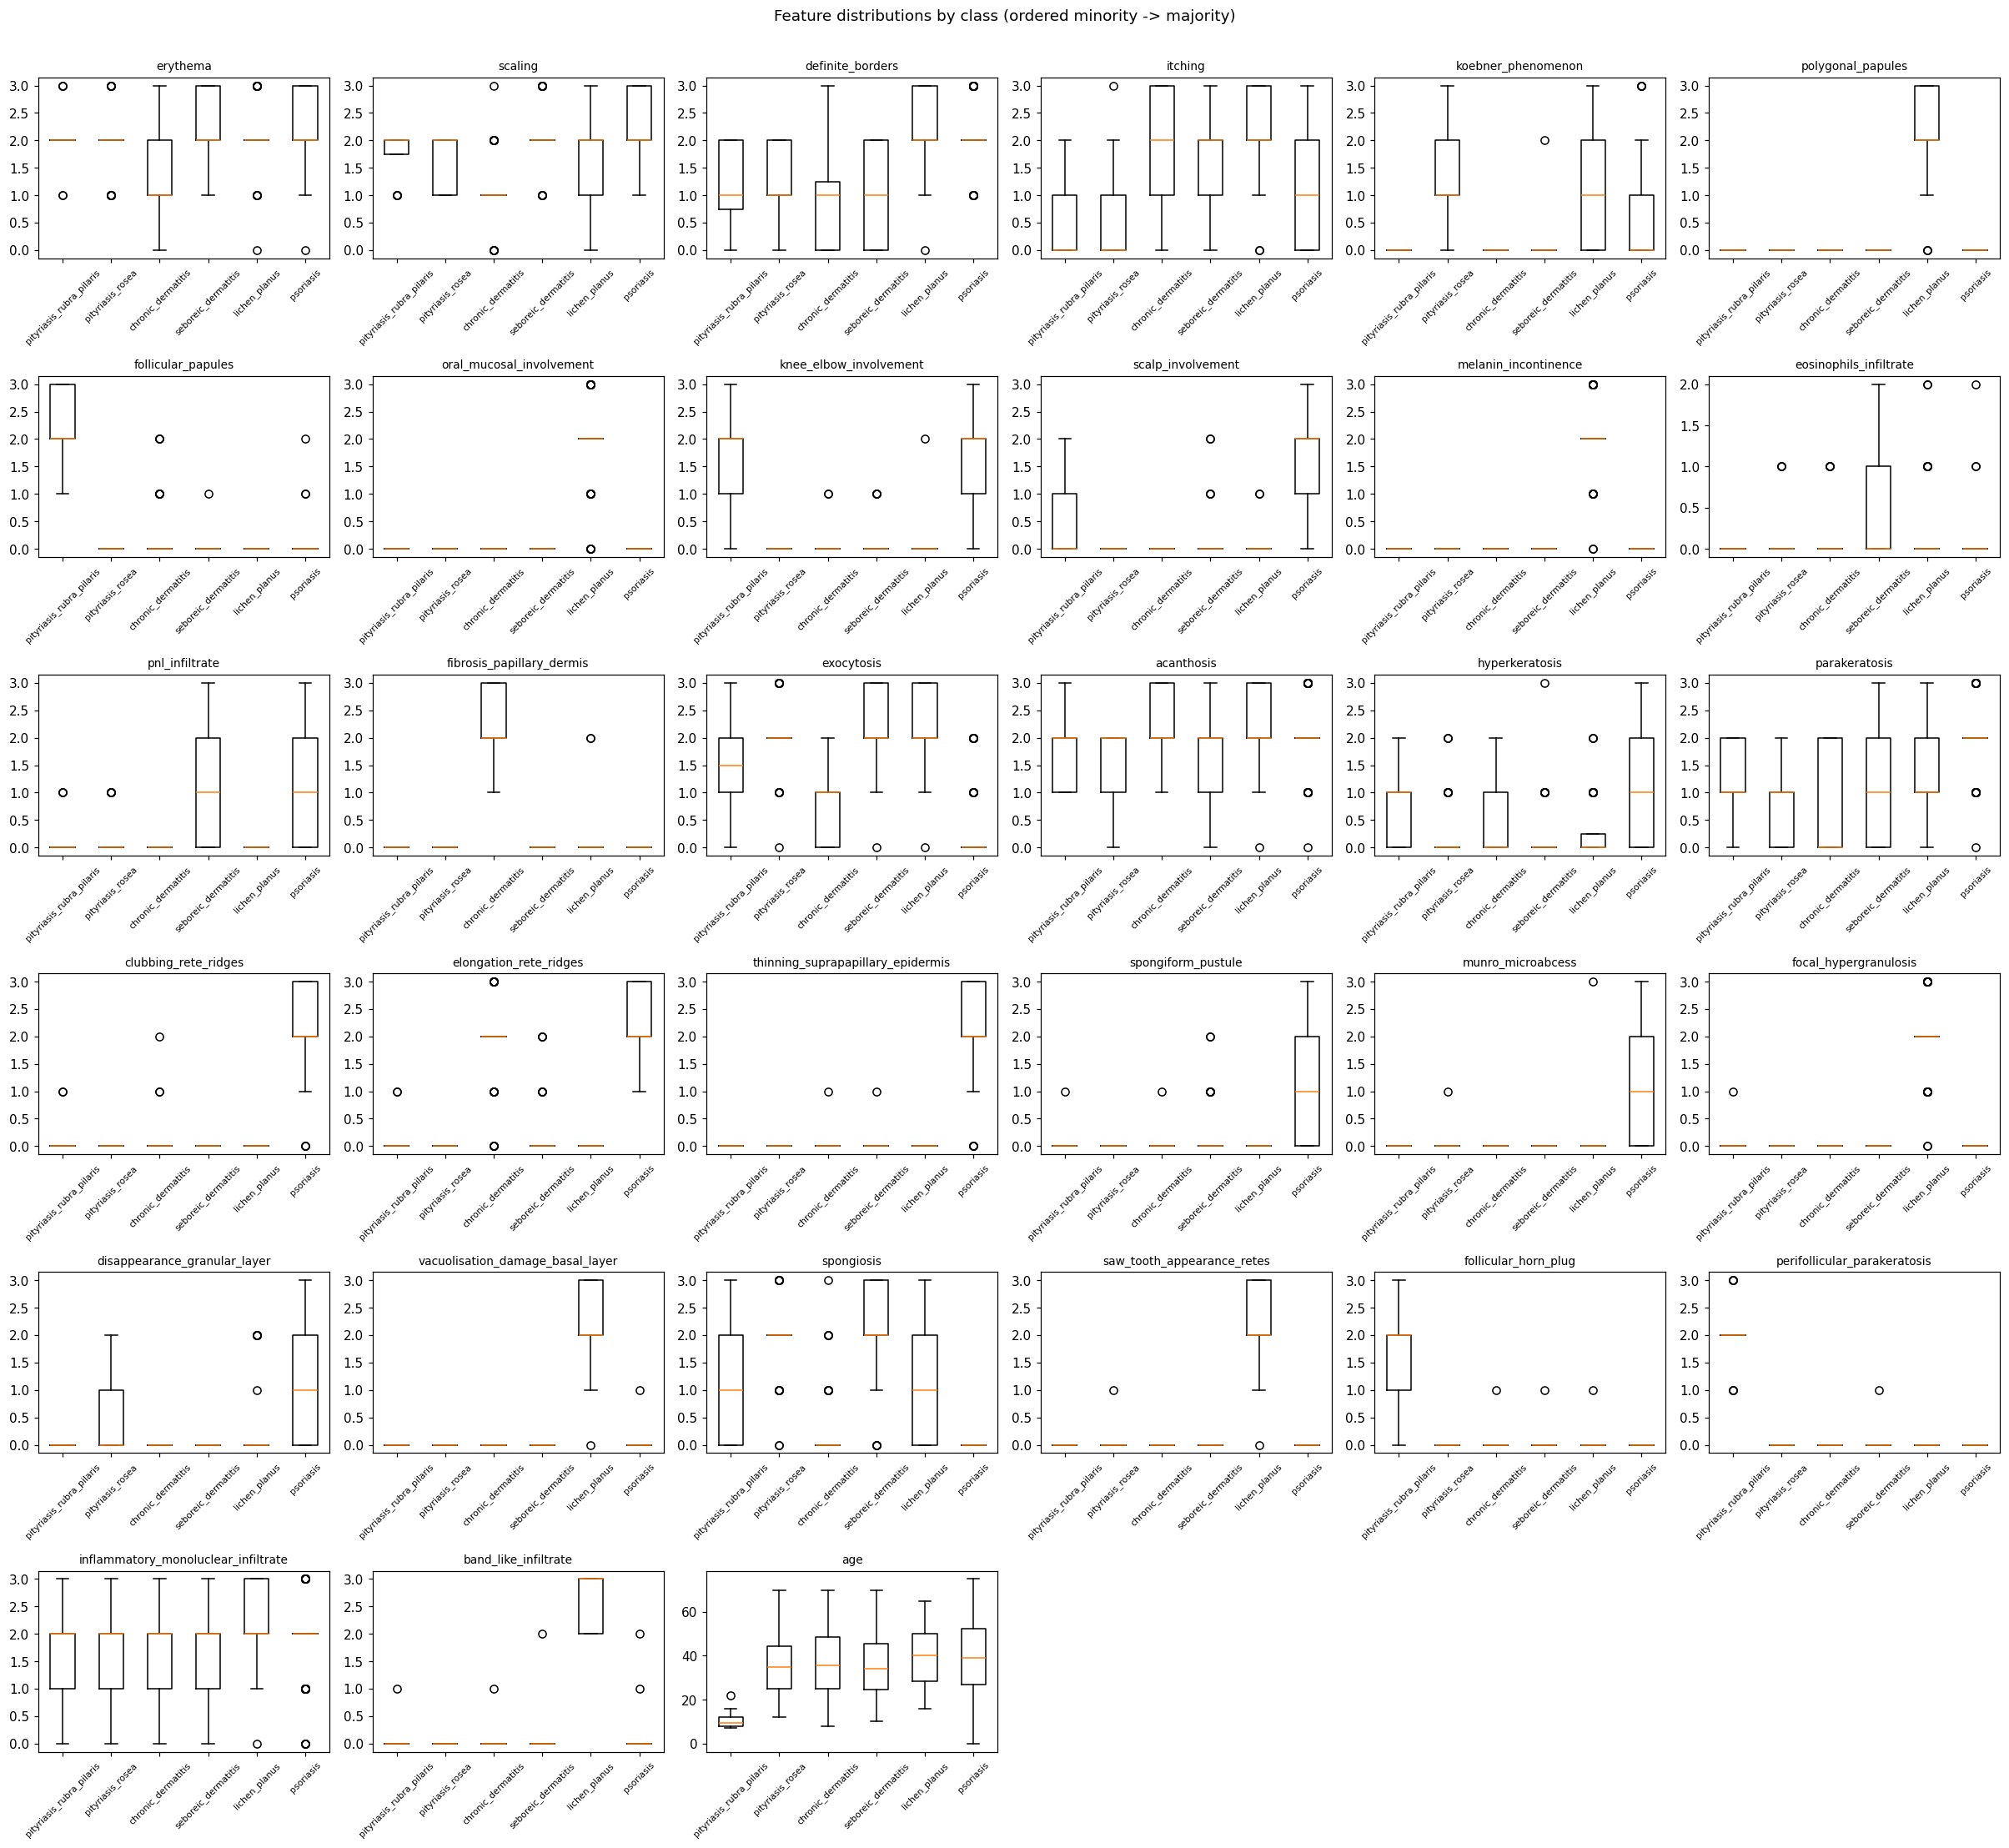

In [ ]:
fig, axes = plt.subplots(6, 6, figsize=(22, 20))
axes = axes.flatten()
for i, feat in enumerate(continuous_feature_cols):
    data_by_class = [df[df["class"] == c][feat].dropna().values for c in minority_to_majority_order]
    axes[i].boxplot(data_by_class, tick_labels=[CLASS_NAMES[c] for c in minority_to_majority_order])
    axes[i].set_title(feat, fontsize=9)
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)
for j in range(len(continuous_feature_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("Feature distributions by class (ordered minority -> majority)", y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab(df["family_history"], df["class"].map(CLASS_NAMES))

class,chronic_dermatitis,lichen_planus,pityriasis_rosea,pityriasis_rubra_pilaris,psoriasis,seboreic_dermatitis
family_history,,,,,,
0,52,71,49,10,80,58
1,0,1,0,10,32,3


Here we are looking if the boxes for different classes sit at different heights for each descriptive feature.

Several features are strongly discriminative, and notably several of them specifically separate out `pityriasis_rubra_pilaris` (the rarest class) on their own:
- `follicular_horn_plug` and `perifollicular_parakeratosis` are essentially only nonzero for `pityriasis_rubra_pilaris` - both sit at 0 for every other class
- `age` is dramatically lower for `pityriasis_rubra_pilaris` (median ~10) with no overlap into the other classes' boxes
- `family_history` is present in 50% of `pityriasis_rubra_pilaris` cases vs 0-29% elsewhere (crosstab above)
- `knee_elbow_involvement` is also elevated specifically for `pityriasis_rubra_pilaris`

Other features separate the majority classes well instead: `scalp_involvement`, `clubbing_rete_ridges`, `elongation_rete_ridges`, `thinning_suprapapillary_epidermis`, and `munro_microabcess` are all near-exclusively elevated for `psoriasis`; `band_like_infiltrate`, `vacuolisation_damage_basal_layer`, and `saw_tooth_appearance_retes` are near-exclusively elevated for `lichen_planus`.

A few features show little to no separation across classes at all: `inflammatory_monoluclear_infiltrate` and `itching` have similar-looking boxes across every class.

Taken together, this explains the high separability seen in the earlier sanity check (~0.96 macro-F1 with plain logistic regression) - it's not that the problem is separable in some diffuse, hard-to-find way, it's that specific features act as near-direct identifiers for specific classes, including the rarest one. That's relevant to the incremental-vs-baseline comparison: `pityriasis_rubra_pilaris` (the class incremental starts on) has unusually strong, easy-to-learn signal despite being the minority class, which is a real structural difference from Glass and Yeast where minority classes weren't necessarily the easiest to separate.

# Saving the data

In [ ]:
df.to_csv(data_dir + "dermatology_clean.csv", index=False)
dist_table.to_csv(data_dir + "class_distribution.csv", index=False)
print(f"Saved to {data_dir}")

Saved to /content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Dermatology/
